# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('drive/MyDrive/Date_Analysis/data/yulu_rental.csv')

In [3]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [4]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4


В одному рядку даних міститься інформація за одну годину.

In [5]:
print(f'В датасеті {df.shape[0]} рядків та {df.shape[1]} колонок.')

В датасеті 10886 рядків та 19 колонок.


## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


In [6]:
day_count = df['count'].resample('D').sum()

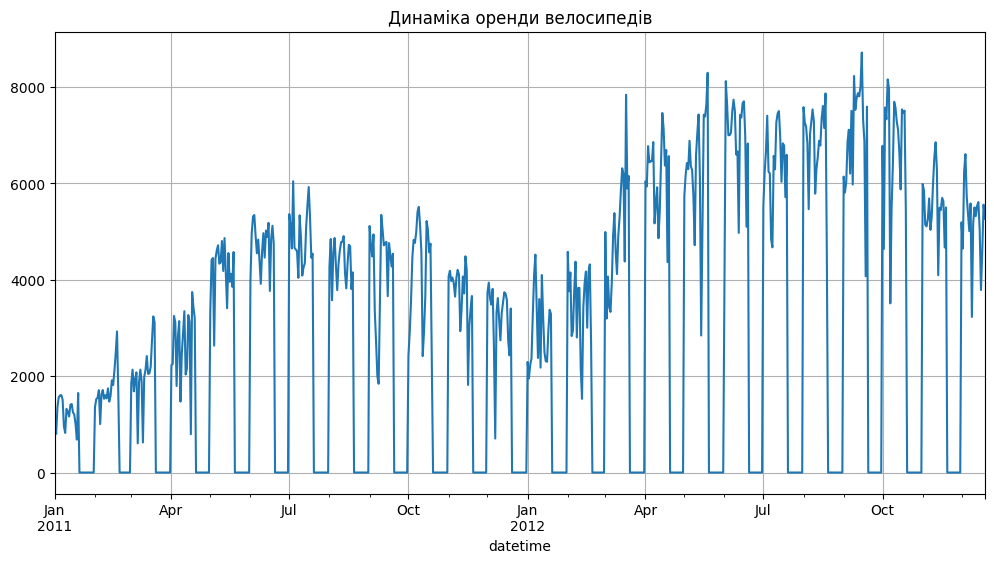

In [7]:
day_count.plot(
    figsize=(12,6),
    title='Динаміка оренди велосипедів',
    grid=True
);

1. Можна припустити, що у нас пропущені дані в ці дні, тому вони відображаються на графіку як 0.

2. В холодний сезон попит нижчий, а в теплий навпаки росте. Також, можна спостерігати, що в 2012 році кількість орендувань значно зросла, порівняно з минулим роком. Це свідчить про те, що бізнес росте, кількість користувачів прокату збільшується.

3. Так, на графіку можна побачити залежність орендувань від сезону: в прохолодний період спостерігаємо зниження кількості орендувань, а в теплий кількість стрімко зростає.

4. В деякі періоди бачимо, що кількість орендувань дорівнює 0, це відбувається приблизно з однаковою частотою, в другій половині кожного місяця. Як я припускала вище, можливо, таким чином відображаються пропущені дані.
Або ж, як варіант, якщо після перевірки цієї теорії виявиться, що дані не пропущено, може бути, що в ці періоди прокат велосипедів не працює, можливо через особливості країни.


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

In [8]:
avg_count = df.groupby('season')['count'].mean()

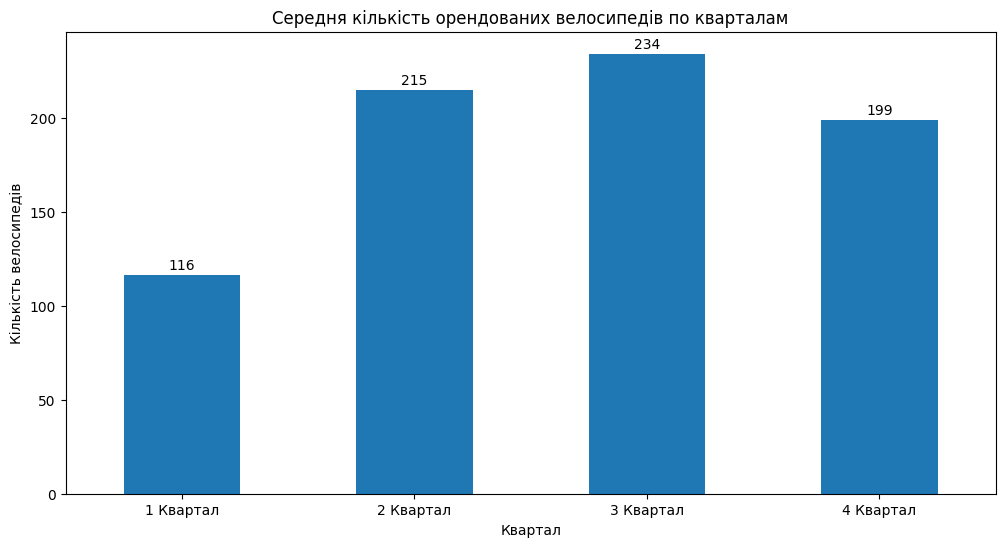

In [9]:
ax = avg_count.plot.bar(
    figsize=(12,6),
    title='Cередня кількість орендованих велосипедів по кварталам',
    xlabel='Квартал',
    ylabel='Кількість велосипедів',
)

quarter_labels = ['1 Квартал', '2 Квартал', '3 Квартал', '4 Квартал']
ax.set_xticklabels(quarter_labels)
plt.xticks(rotation=0)

for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width()/2,
        p.get_height() + 3,
        f'{p.get_height():.0f}',
        ha='center'
    );

1. Найбільша середня кількість оренди велосипедів в третьому кварталі.

2. Думаю, це повязано з погодними умовами, в третьому карталі найсприятливіші місяці для проведення часу на свіжому повітрі.

3. Оренда в 3му кварталі в два рази більша ніж в 1му кварталі.

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


In [10]:
avg_quantity = df.groupby('month')['count'].mean()

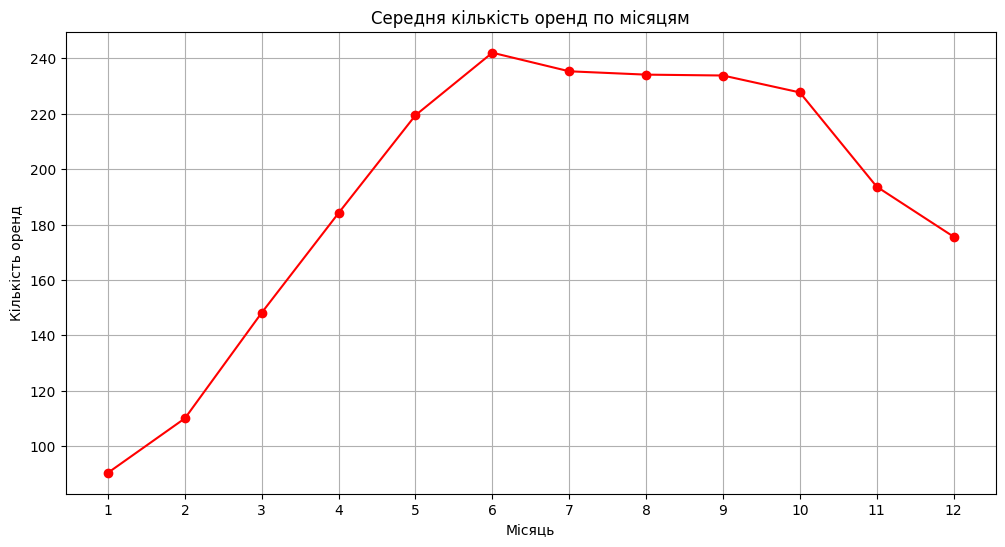

In [11]:
ax = avg_quantity.plot(
    figsize=(12,6),
    marker='o',
    color='red',
    grid=True,
    xlabel='Місяць',
    ylabel='Кількість оренд',
    title='Середня кількість оренд по місяцям'
)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(range(1, 13));

1. Пік спостерігаємо в червні, і він, з незначним спадом, тримається до вересня, стрімкий спад починається в жовтні.
2. Так, збігається.
3. Погодні умови напряму впливають на бажання людей орендувати велосипеди. В гарну теплу погоду рівень бажання людей проводити дозвілля на вулиці, звичайно, що високий, а з настанням холодів цей спосіб стає не надто популярним.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

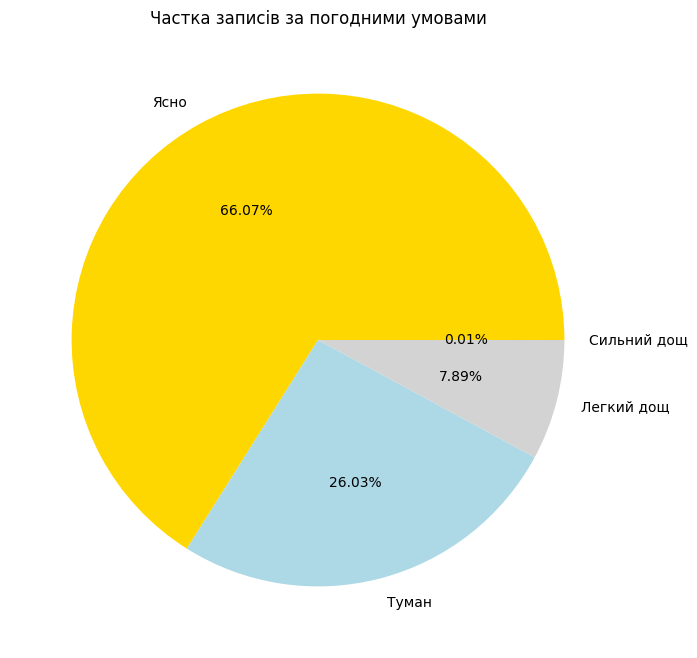

In [12]:
weather_cond = df.groupby('weather')['weather'].count()

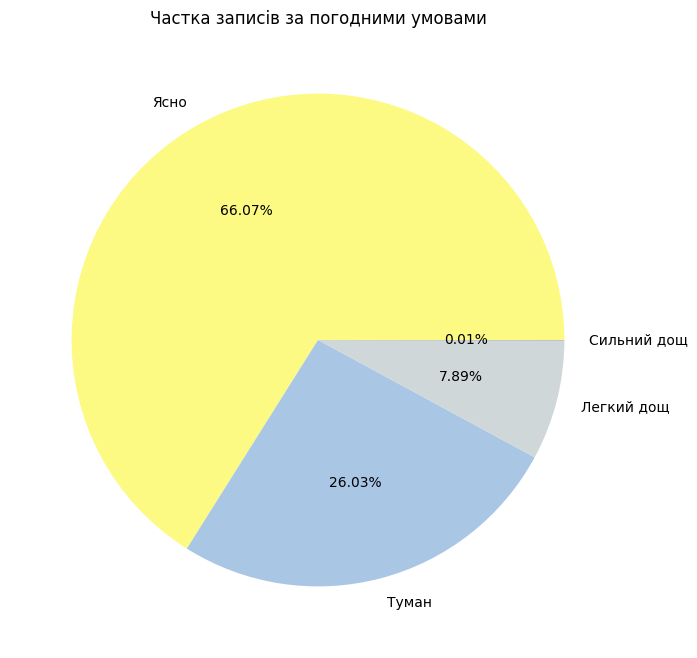

In [13]:
weather_colors = ['#FCFA82', '#A9C7E5', '#D0D7D9', '#252849']

weather_cond.plot.pie(
   figsize=(8,8),
   colors=weather_colors,
   autopct = '%1.2f%%',
   labels=['Ясно','Туман','Легкий дощ','Сильний дощ'],
   ylabel='',
   title='Частка записів за погодними умовами'
);


1. В датасеті переважає ясна погода.
2. Дуже мало днів, коли йшов сильний дощ, частка таких днів одна сота відсотка.
3. Думаю, що в дні, коли ясно, попит на велосипеди набагато вище, ніж коли туманно або йде дощ.

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

In [14]:
df.groupby('weather')['count'].sum()

,count
weather,
1,1476063
2,507160
3,102089
4,164


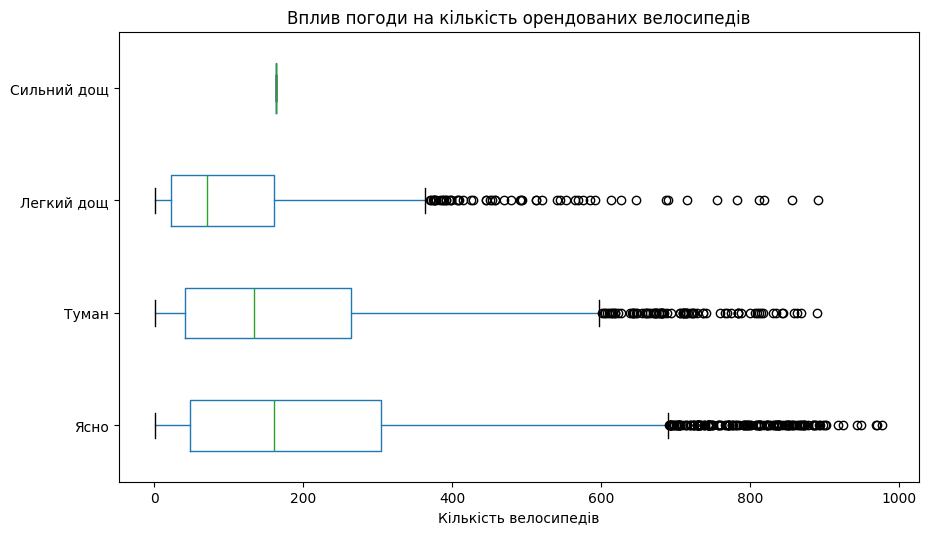

In [15]:
ax = df.boxplot(
    column='count',
    by='weather',
    figsize=(10,6),
    grid=False,
    vert=False
)
plt.title('Вплив погоди на кількість орендованих велосипедів')
plt.suptitle('')
plt.xlabel('Кількість велосипедів')
plt.ylabel('')

weather_labels = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']
ax.set_yticklabels(weather_labels);

1. Коли погода *ясна* бачимо найбільший розкид по кількості орендованих велосипедів.
2. *Ясно*, *туман* та *легкий дощ* - бачимо викиди в даних при кожній погоді.
3. Спостерігаємо найвище медіанне значення коли погода *ясна*.

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

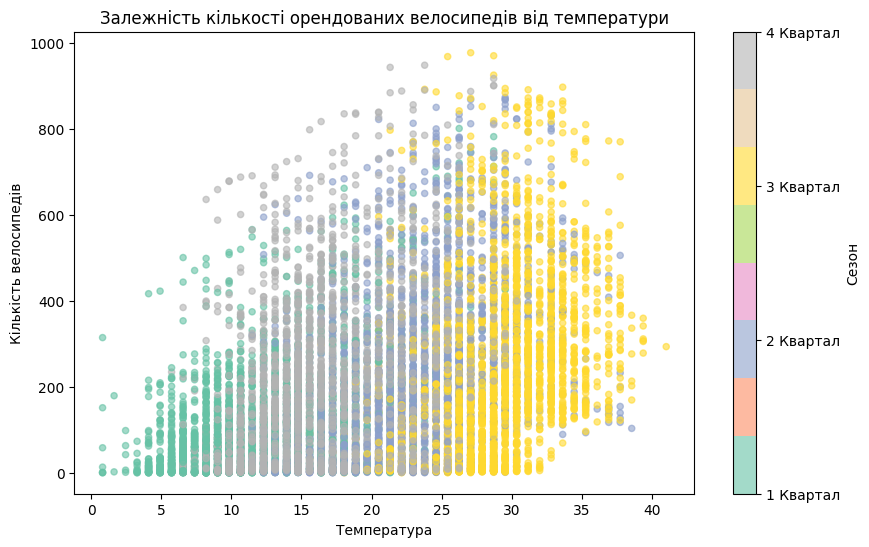

In [31]:
ax = df.plot.scatter(
    x='temp',
    y='count',
    c='season',
    colormap='Set2',
    colorbar=False,
    figsize=(10,6),
    alpha=0.6,
    title='Залежність кількості орендованих велосипедів від температури',
    xlabel='Температура',
    ylabel='Кількість велосипедів'
)

scatter = ax.collections[0]

cbar = plt.colorbar(scatter)
cbar.set_label('Сезон')

cbar.set_ticks([1, 2, 3, 4])
cbar.set_ticklabels(['1 Квартал', '2 Квартал', '3 Квартал', '4 Квартал'])

plt.show()

Так, очевидна залежність між температорую та кількість орендованих велосипедів. При низькій температурі, можемо спостерігати на графіку, що орендують мало велосипедів. Чим більша температура, тим більше велосипедів орендують. Тобто, спостерігаємо позитивну кореляцію.

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

In [55]:
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['weekday_cat'] = pd.Categorical(df['weekday'], categories=ordered_days, ordered=True)

In [64]:
data_week = df.groupby('weekday_cat', observed=True)[['casual', 'registered']].mean()

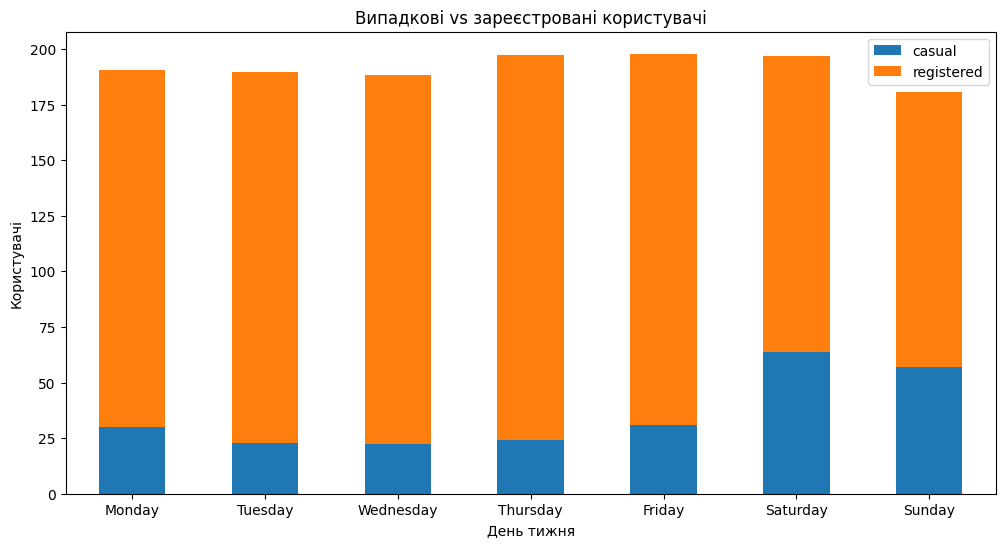

In [62]:
data_week.plot.bar(
    figsize=(12,6),
    stacked=True,
    xlabel = 'День тижня',
    ylabel = 'Користувачі',
    title='Випадкові vs зареєстровані користувачі'
)
plt.xticks(rotation=0);

1. У середньому найбільше оренд від зареєстрованих користувачів в четверг, також достатньо багато оренд у вівторог та п'ятницю
2. Доволі цікаво, що у вихідні дні кількість зареєстрованих користувачів найменша, і різниця доволі суттєва, порівнюючи з робочими днями. Можу припустити, що можливо в ці дні якісь додаткові знижки або бонуси для зареєстрованих користувачів.